# Closed-form RNNs for $C_n\times C_n$

This notebook constructs a quadratic RNN whose recurrent state realizes translation on the finite square torus

$$G=C_n\times C_n.$$

A vector $x\in\mathbb R^{n^2}$ is identified with a scalar signal $x:G\to\mathbb R$. Because this group is abelian, every irreducible representation is one-dimensional. This makes the construction the simplest two-dimensional counterpart of the discrete-$SE(2)$ notebook: it retains the same encoding, weight, rollout, reconstruction, trajectory, and tuning diagnostics, but has no orientation coordinate or semidirect-product rotation.

We first verify an exact all-irrep model on a small group, then use ten Fourier modes for an approximate $n=50$ spatial experiment.

In [1]:
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

project_root = next(
    parent
    for parent in (Path.cwd(), *Path.cwd().parents)
    if (parent / "src").is_dir()
)
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from src.cnxcn_geometry import (
    TRACK_COLOR,
    center_errors,
    decode_spatial_argmax,
    gaussian_bump,
    make_momentum_motion_sequence,
    plot_grid_scalar,
    plot_grid_trajectory,
    signal_to_grid,
    transformed_center,
)
from src.finite_group_rnn import (
    build_finite_group_rnn,
    hidden_width,
    probe_hidden_states,
    random_invertible_encoding,
    rollout,
)
from src.groups import ProductCyclicGroup

np.set_printoptions(precision=3, suppress=True)

## 1. Group, action, and Fourier structure

Write $g=(a,b)$ with $a,b\in C_n$. The group law is componentwise addition,

$$(a,b)(c,d)=(a+c,b+d)\pmod n,$$

and the regular left action is

$$(g\cdot x)[h]=x[g^{-1}h].$$

Equivalently, $g$ translates the $n\times n$ signal on a periodic square grid. The irreps are the two-dimensional Fourier characters

$$\rho_{k,\ell}(a,b)=\exp\left[2\pi i\left(\frac{ka}{n}+\frac{\ell b}{n}\right)\right].$$

There are $n^2$ one-dimensional irreps, so $\sum_\rho d_\rho^2=n^2=|G|$. Unlike discrete $SE(2)$, the group is abelian and contains no orientation coordinate.

In [2]:
G_exact = ProductCyclicGroup(4, 4)
irreps_exact = G_exact.irreps()
print(f"|G|={G_exact.order}; number of irreps={len(irreps_exact)}")
print("irrep dimensions:", sorted({irrep.dim for irrep in irreps_exact}))
print("Peter–Weyl sum:", sum(irrep.dim**2 for irrep in irreps_exact))
assert sum(irrep.dim**2 for irrep in irreps_exact) == G_exact.order

rng = np.random.default_rng(7)
x_allo_exact = rng.normal(size=G_exact.order)
x_ego_exact = random_invertible_encoding(G_exact, irreps_exact, seed=11)
params_exact = build_finite_group_rnn(
    G_exact,
    x_ego_exact,
    irrep_selection="all",
    materialize_mix=False,
)
expected_width = sum(hidden_width(irrep) for irrep in irreps_exact)
print("all-irrep hidden width:", params_exact.hidden_dim)
assert params_exact.hidden_dim == expected_width

|G|=16; number of irreps=16
irrep dimensions: [1]
Peter–Weyl sum: 16
all-irrep hidden width: 192


## 2. Exact all-irrep check

With every Fourier character retained, the closed-form network must reproduce periodic translations to floating-point precision. The multistep sequence also checks accumulation, although—unlike $SE(2)$—all translations commute.

In [3]:
exact_sequences = {
    "x translation": [G_exact.encode(1, 0)],
    "y translation": [G_exact.encode(0, -1)],
    "multistep": [
        G_exact.encode(1, 0),
        G_exact.encode(0, 1),
        G_exact.encode(-1, 1),
    ],
}
for name, sequence in exact_sequences.items():
    result = rollout(params_exact, x_allo_exact, sequence)
    error = np.max(np.abs(result["predicted_outputs"] - result["true_outputs"]))
    print(f"{name:16s} max absolute error={error:.3e}")
    assert error < 1e-10

x_step = G_exact.encode(1, 0)
y_step = G_exact.encode(0, 1)
assert G_exact.compose(x_step, y_step) == G_exact.compose(y_step, x_step)
print("x and y translations commute: True")

x translation    max absolute error=1.443e-15
y translation    max absolute error=2.720e-15
multistep        max absolute error=3.664e-15
x and y translations commute: True


## 3. Fourier-truncated spatial experiment

The normal configuration matches the spatial scale used in the $SE(2)$ notebook: $n=50$, `center_xy=(2,2)`, $\sigma=1$, ten retained irreps, and egocentric-code seed 10. `NOTEBOOK_TEST_MODE=1` uses $n=12$ and six modes.

Because all irreps are one-dimensional, each retained Fourier mode contributes only 12 hidden units. This makes a large grid inexpensive even though the model is deliberately approximate.

In [4]:
test_mode = os.environ.get("NOTEBOOK_TEST_MODE") == "1"
n_spatial = 12 if test_mode else 50
num_selected_irreps = 6 if test_mode else 10

G = ProductCyclicGroup(n_spatial, n_spatial)
center_xy = (2, 2)
sigma = 1.0
x_allo = gaussian_bump(G, center=center_xy, sigma=sigma)
all_irreps = G.irreps()
x_ego = random_invertible_encoding(G, all_irreps, seed=10)
params = build_finite_group_rnn(
    G,
    x_ego,
    x_allo=x_allo,
    irreps=all_irreps,
    irrep_selection="power",
    num_irreps=num_selected_irreps,
    materialize_mix=False,
)

print(f"|G|={G.order}; all irreps={len(all_irreps)}")
print("selected Fourier modes:", params.selected_irrep_indices)
print("hidden width:", params.hidden_dim)
print("W_mix stored:", params.W_mix is not None)

|G|=2500; all irreps=2500
selected Fourier modes: [0, 1, 49, 50, 51, 99, 2400, 2450, 2451, 2499]
hidden width: 120
W_mix stored: False


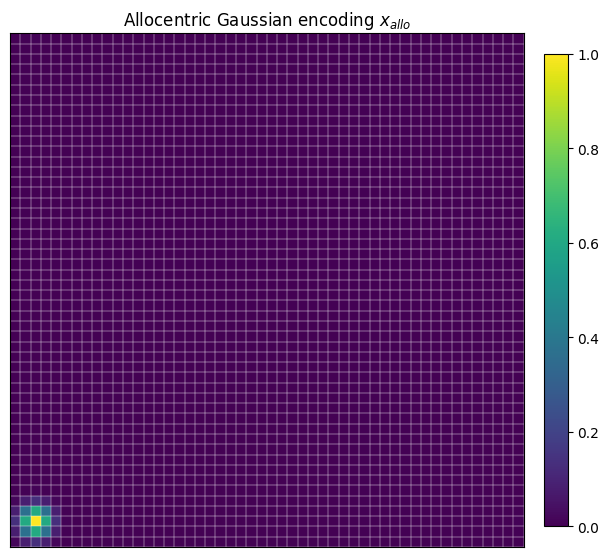

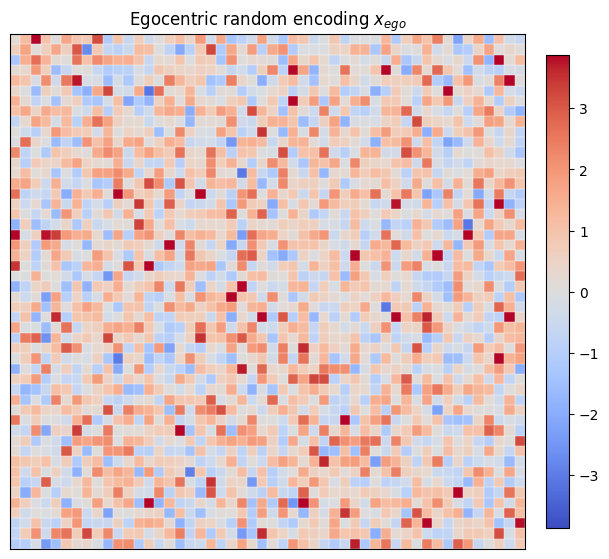

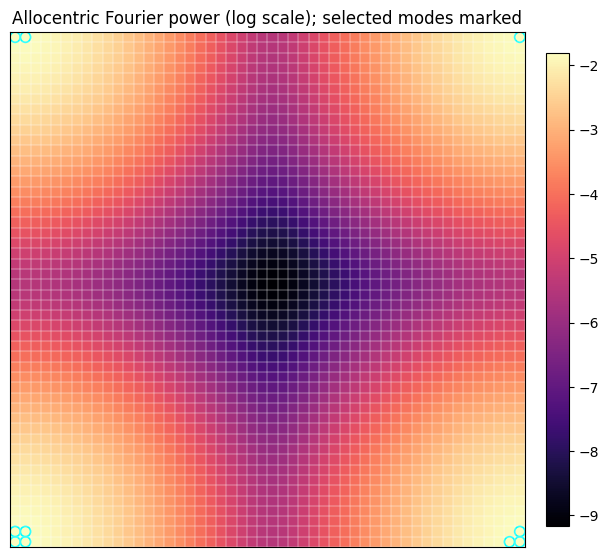

In [5]:
plot_grid_scalar(
    signal_to_grid(G, x_allo),
    title="Allocentric Gaussian encoding $x_{allo}$",
)
plt.show()

x_ego_grid = signal_to_grid(G, x_ego)
ego_scale = np.percentile(np.abs(x_ego_grid), 99)
plot_grid_scalar(
    x_ego_grid,
    title="Egocentric random encoding $x_{ego}$",
    cmap="coolwarm",
    vmin=-ego_scale,
    vmax=ego_scale,
)
plt.show()

power = G.power_spectrum(x_allo)
power_grid = power.reshape(G.p1, G.p2)
ax = plot_grid_scalar(
    np.log10(power_grid + 1e-14),
    title="Allocentric Fourier power (log scale); selected modes marked",
    cmap="magma",
)
selected_frequencies = np.asarray(
    [G.decode(index) for index in params.selected_irrep_indices]
)
ax.scatter(
    selected_frequencies[:, 0],
    selected_frequencies[:, 1],
    s=55,
    marker="o",
    facecolors="none",
    edgecolors="cyan",
    linewidths=1.2,
)
plt.show()

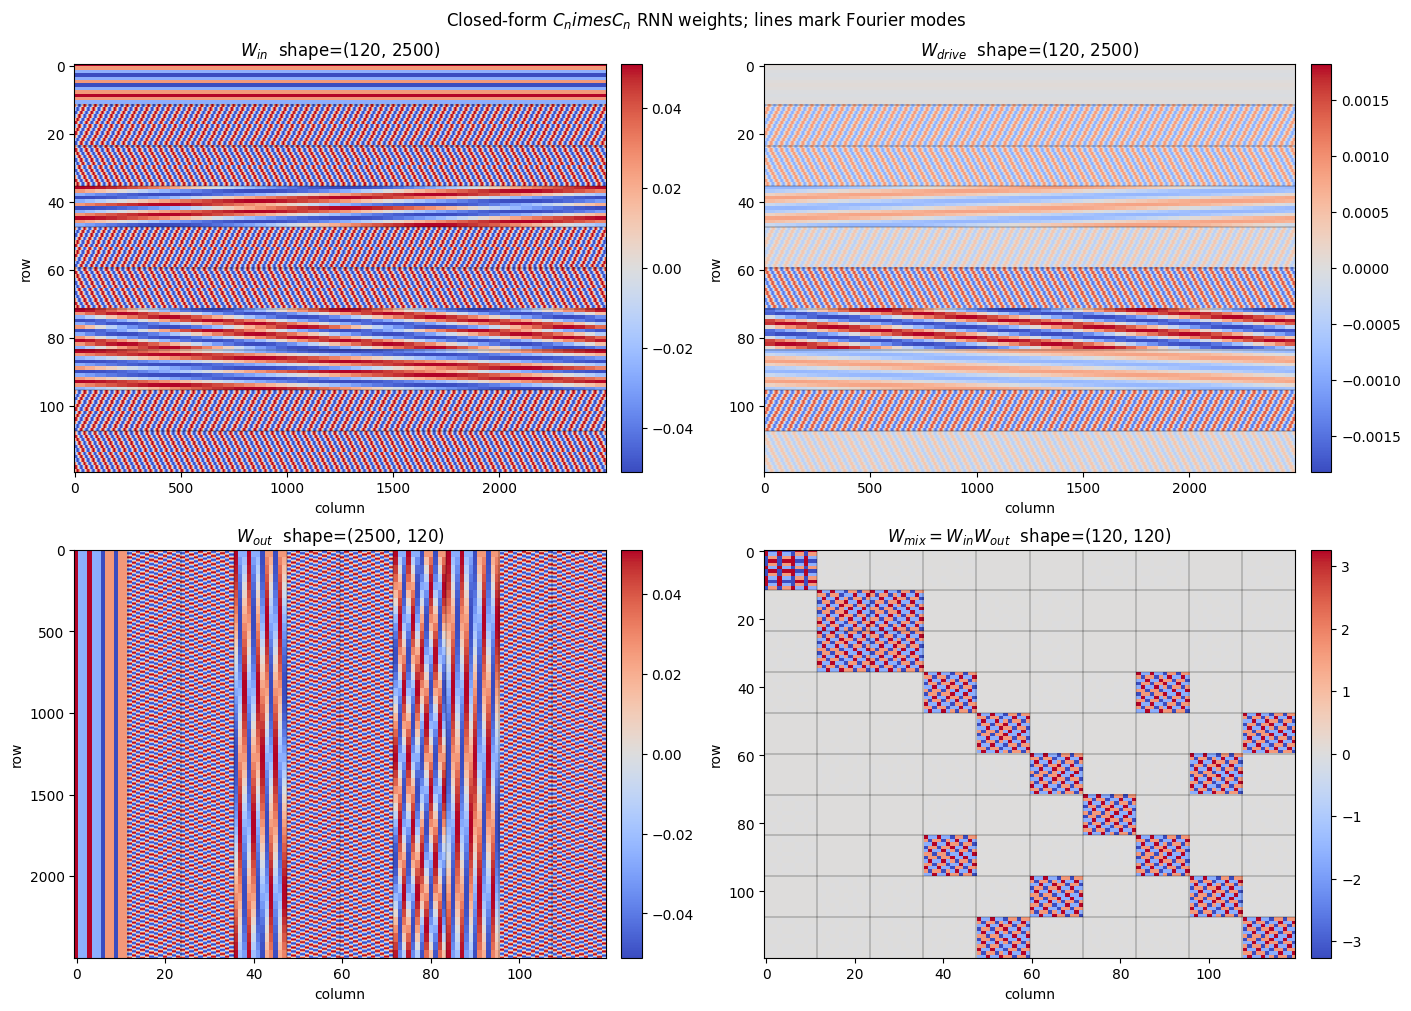

In [6]:
W_mix_for_plot = params.W_in @ params.W_out
weight_matrices = {
    r"$W_{in}$": params.W_in,
    r"$W_{drive}$": params.W_drive,
    r"$W_{out}$": params.W_out,
    r"$W_{mix}=W_{in}W_{out}$": W_mix_for_plot,
}
metadata_irreps = np.asarray([item["irrep_index"] for item in params.metadata])
block_boundaries = np.flatnonzero(np.diff(metadata_irreps)) + 1

figure, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for panel, (ax, (name, matrix)) in enumerate(
    zip(axes.ravel(), weight_matrices.items())
):
    scale = np.percentile(np.abs(matrix), 99)
    image = ax.imshow(
        matrix,
        aspect="auto",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-scale,
        vmax=scale,
    )
    if panel in (0, 1, 3):
        for boundary in block_boundaries:
            ax.axhline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    if panel in (2, 3):
        for boundary in block_boundaries:
            ax.axvline(boundary - 0.5, color="black", linewidth=0.35, alpha=0.7)
    ax.set_title(f"{name}  shape={matrix.shape}")
    ax.set_xlabel("column")
    ax.set_ylabel("row")
    figure.colorbar(image, ax=ax, fraction=0.046, pad=0.03)
figure.suptitle("Closed-form $C_n\times C_n$ RNN weights; lines mark Fourier modes")
plt.show()

del W_mix_for_plot

## 4. Short translation rollouts

We separately report full-signal reconstruction error and decoded-center error. Fourier truncation can preserve the Gaussian peak even when it changes the bump's shape or amplitude.

In [7]:
def summarize_rollout(name, sequence):
    result = rollout(params, x_allo, sequence)
    absolute_errors = np.linalg.norm(
        result["predicted_outputs"] - result["true_outputs"], axis=1
    )
    relative_errors = absolute_errors / np.linalg.norm(
        result["true_outputs"], axis=1
    )
    exact_centers = np.asarray(
        [transformed_center(G, int(state), center_xy) for state in result["cumulative_states"]]
    )
    predicted_centers = np.asarray(
        [decode_spatial_argmax(G, output) for output in result["predicted_outputs"]]
    )
    position_errors = center_errors(G, predicted_centers, exact_centers)
    print(
        f"{name:16s} final relative signal={relative_errors[-1]:.3e}; "
        f"max center={position_errors.max():.3f}"
    )
    return {
        "rollout": result,
        "absolute_errors": absolute_errors,
        "relative_errors": relative_errors,
        "position_errors": position_errors,
        "exact_centers": exact_centers,
        "predicted_centers": predicted_centers,
    }

short_sequences = {
    "x translation": [G.encode(1, 0)] * 6,
    "y translation": [G.encode(0, 1)] * 6,
    "mixed": [
        G.encode(1, 0),
        G.encode(0, 1),
        G.encode(-1, 0),
        G.encode(1, -1),
        G.encode(0, 1),
        G.encode(1, 0),
    ],
}
short_results = {
    name: summarize_rollout(name, sequence)
    for name, sequence in short_sequences.items()
}

x translation    final relative signal=9.775e-01; max center=0.000
y translation    final relative signal=9.775e-01; max center=0.000
mixed            final relative signal=9.775e-01; max center=0.000


## 5. Long momentum rollout

The 250-step bounded random walk uses the same presentation as the discrete-$SE(2)$ experiment: the first relative translation moves the bump near the arena center, subsequent local translations have momentum with occasional turns and stays, and exact and decoded centers are overlaid on a neutral lattice.

long trajectory  final relative signal=9.776e-01; max center=0.000
Long-sequence tracking summary
------------------------------
max output error:    1.7329378961887847
mean output error:   1.732880794715103
max center error:    0.0
mean center error:   0.0


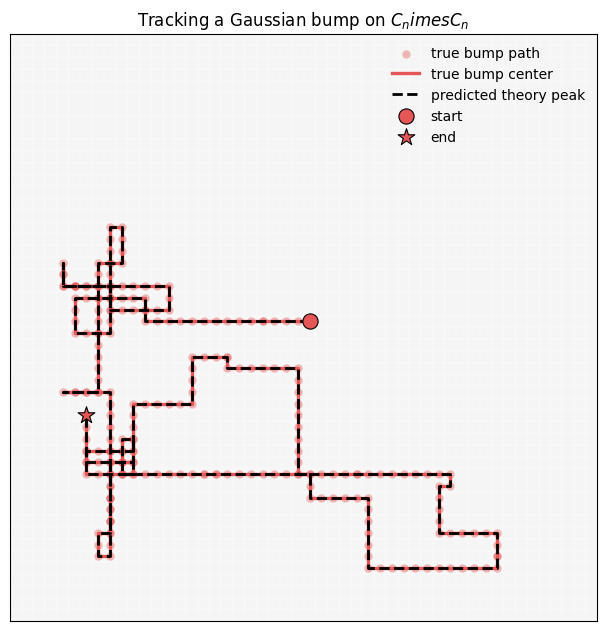

In [8]:
num_long_steps = 80 if test_mode else 250
start_xy = (
    (G.p1 // 2 - center_xy[0]) % G.p1,
    (G.p2 // 2 - center_xy[1]) % G.p2,
)
long_sequence = make_momentum_motion_sequence(
    G,
    steps=num_long_steps,
    seed=1,
    turn_probability=0.18,
    stay_probability=0.04,
    start_xy=start_xy,
)
long = summarize_rollout("long trajectory", long_sequence)

print("Long-sequence tracking summary")
print("------------------------------")
print("max output error:   ", long["absolute_errors"].max())
print("mean output error:  ", long["absolute_errors"].mean())
print("max center error:   ", long["position_errors"].max())
print("mean center error:  ", long["position_errors"].mean())

plot_grid_trajectory(
    G,
    long["exact_centers"],
    long["predicted_centers"],
    title="Tracking a Gaussian bump on $C_n\times C_n$",
)
plt.show()

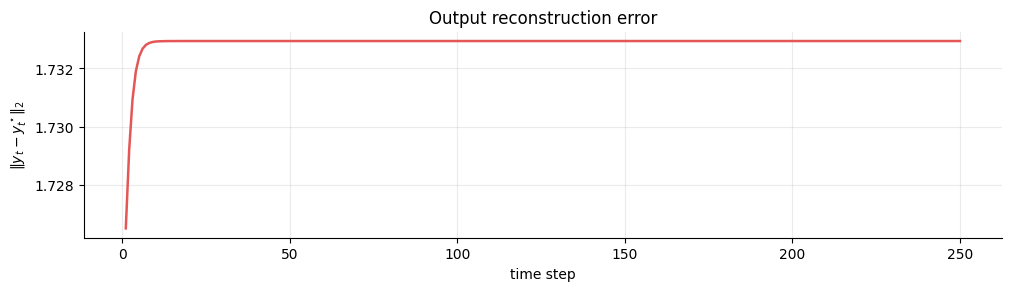

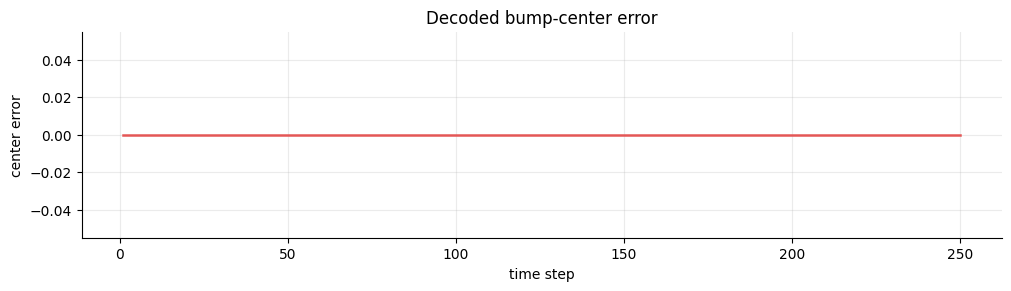

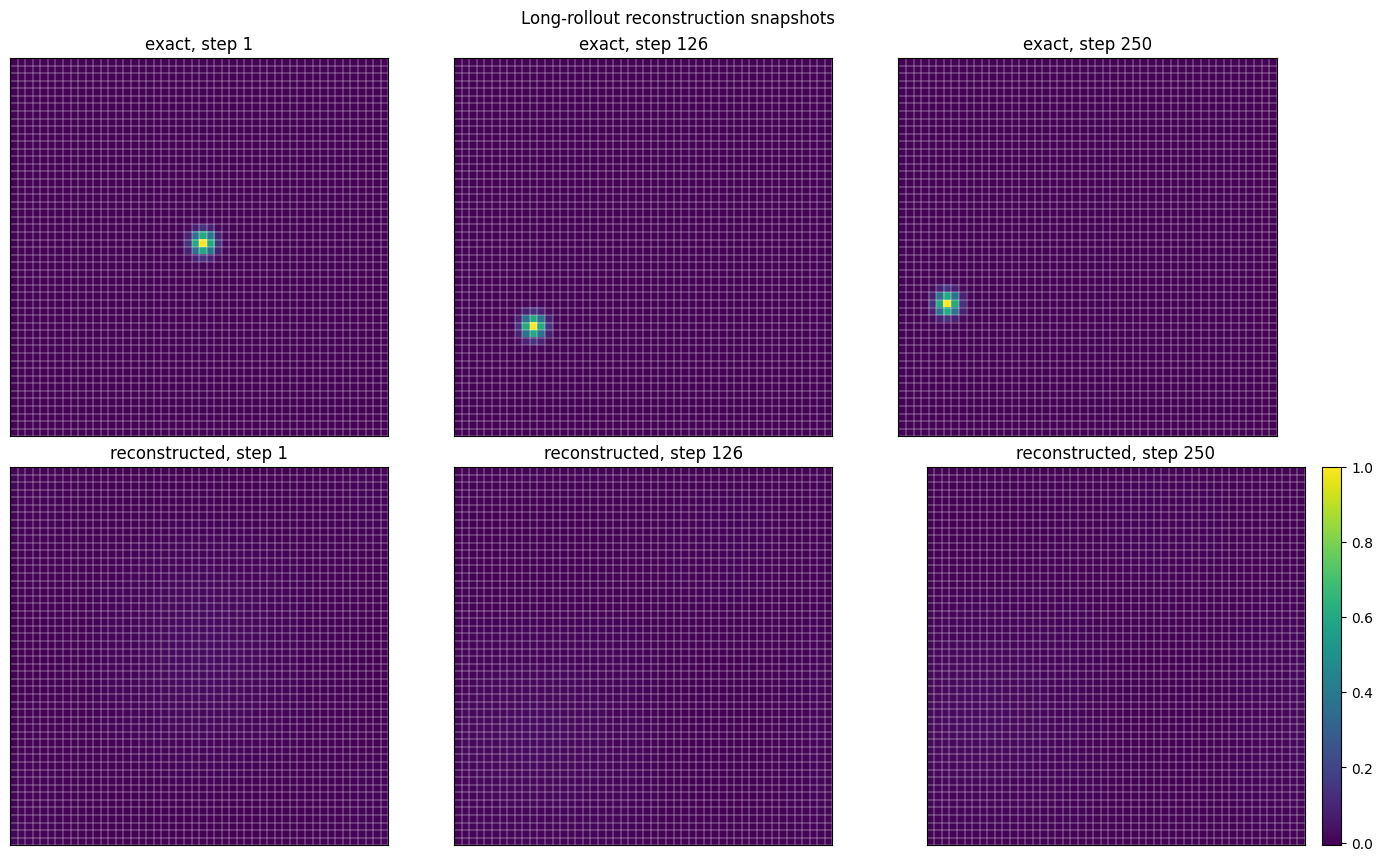

In [9]:
time = np.arange(1, num_long_steps + 1)
for values, ylabel, title in (
    (long["absolute_errors"], r"$\|y_t-y_t^\star\|_2$", "Output reconstruction error"),
    (long["position_errors"], "center error", "Decoded bump-center error"),
):
    figure, ax = plt.subplots(figsize=(10, 2.8), constrained_layout=True)
    ax.plot(time, values, color=TRACK_COLOR, linewidth=1.8)
    ax.set(xlabel="time step", ylabel=ylabel, title=title)
    ax.grid(True, alpha=0.25)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.show()

snapshot_steps = [0, num_long_steps // 2, num_long_steps - 1]
figure, axes = plt.subplots(2, 3, figsize=(14, 8.5), constrained_layout=True)
snapshot_values = [
    signal_to_grid(G, long["rollout"][key][step])
    for key in ("true_outputs", "predicted_outputs")
    for step in snapshot_steps
]
vmin = min(float(values.min()) for values in snapshot_values)
vmax = max(float(values.max()) for values in snapshot_values)
for column, step in enumerate(snapshot_steps):
    plot_grid_scalar(
        signal_to_grid(G, long["rollout"]["true_outputs"][step]),
        ax=axes[0, column],
        title=f"exact, step {step + 1}",
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
    )
    plot_grid_scalar(
        signal_to_grid(G, long["rollout"]["predicted_outputs"][step]),
        ax=axes[1, column],
        title=f"reconstructed, step {step + 1}",
        vmin=vmin,
        vmax=vmax,
        colorbar=column == 2,
    )
figure.suptitle("Long-rollout reconstruction snapshots")
plt.show()

## 6. Hidden-state tuning

These are static probes over all translated allocentric inputs with the egocentric drive fixed at the identity. We select one hidden unit from each of six distinct nonconstant Fourier modes. Since $C_n\times C_n$ has no orientation coordinate, each tuning curve is already a single square-grid field; no direction alignment or marginalization is needed. Raw activations share one color scale.

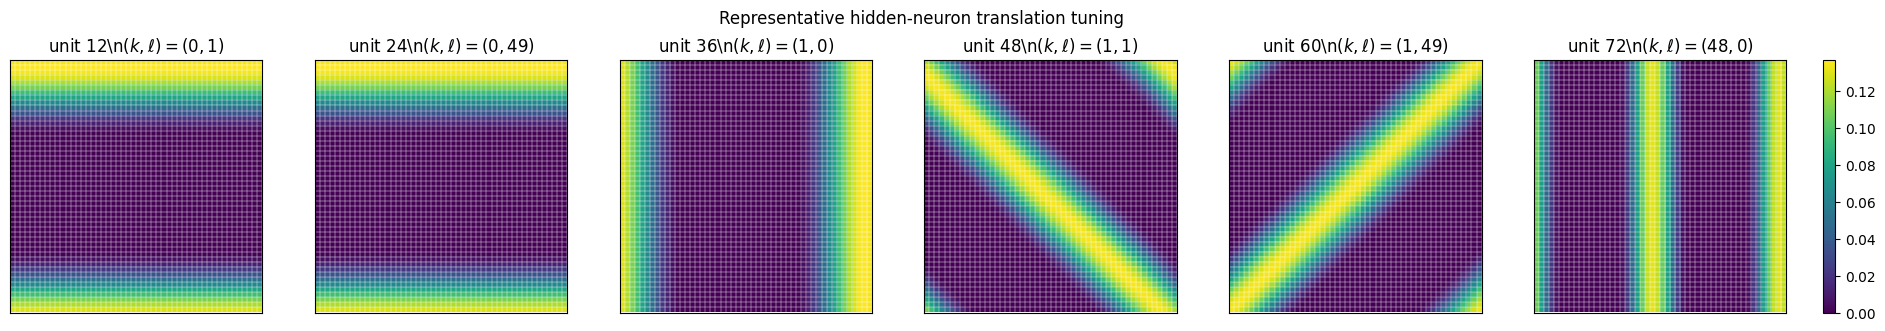

Selected tuning units
---------------------
12 {'irrep_index': 1, 'irrep_name': 'C50xC50|[irrep_0,1]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
24 {'irrep_index': 49, 'irrep_name': 'C50xC50|[irrep_0,49]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
36 {'irrep_index': 50, 'irrep_name': 'C50xC50|[irrep_1,0]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
48 {'irrep_index': 51, 'irrep_name': 'C50xC50|[irrep_1,1]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
60 {'irrep_index': 99, 'irrep_name': 'C50xC50|[irrep_1,49]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}
72 {'irrep_index': 2400, 'irrep_name': 'C50xC50|[irrep_48,0]:1', 'irrep_dim': 1, 'eps1': 1, 'eps2': 1, 'delta': 0, 'k0': 0, 'k1': 0, 'k2': 0}


In [10]:
static_hidden = probe_hidden_states(params, x_allo)
representatives = []
seen_irreps = set()
for unit, metadata in enumerate(params.metadata):
    irrep_index = metadata["irrep_index"]
    if irrep_index == 0 or irrep_index in seen_irreps:
        continue
    representatives.append(unit)
    seen_irreps.add(irrep_index)
    if len(representatives) == 6:
        break

tuning_fields = [signal_to_grid(G, static_hidden[:, unit]) for unit in representatives]
vmin = min(float(field.min()) for field in tuning_fields)
vmax = max(float(field.max()) for field in tuning_fields)
figure, axes = plt.subplots(
    1,
    len(representatives),
    figsize=(3.2 * len(representatives), 3.2),
    constrained_layout=True,
)
axes = np.atleast_1d(axes)
for ax, unit, field in zip(axes, representatives, tuning_fields):
    irrep_index = params.metadata[unit]["irrep_index"]
    frequency = G.decode(irrep_index)
    plot_grid_scalar(
        field,
        ax=ax,
        title=rf"unit {unit}\n$(k,\ell)={frequency}$",
        vmin=vmin,
        vmax=vmax,
        colorbar=False,
    )
colorbar = plt.cm.ScalarMappable(
    norm=plt.Normalize(vmin=vmin, vmax=vmax),
    cmap=plt.get_cmap("viridis"),
)
colorbar.set_array([])
figure.colorbar(colorbar, ax=axes, fraction=0.025, pad=0.02)
figure.suptitle("Representative hidden-neuron translation tuning")
plt.show()

print("Selected tuning units")
print("---------------------")
for unit in representatives:
    print(unit, params.metadata[unit])

In [11]:
retained_fraction = power[params.selected_irrep_indices].sum() / power.sum()
all_width = sum(hidden_width(irrep) for irrep in all_irreps)
print(f"retained Fourier power: {retained_fraction:.2%}")
print(f"selected hidden width: {params.hidden_dim:,}")
print(f"all-irrep hidden width: {all_width:,}")
print(f"width reduction: {1 - params.hidden_dim / all_width:.2%}")

retained Fourier power: 4.90%
selected hidden width: 120
all-irrep hidden width: 30,000
width reduction: 99.60%


## 7. Conclusions and limitations

- The small all-irrep model reproduces the regular action of $C_n\times C_n$ to floating-point precision.
- The $n=50$ experiment retains ten Fourier characters and is therefore approximate; signal reconstruction and decoded-center errors measure different consequences of truncation.
- Every irrep is one-dimensional, so hidden width grows as $12$ units per selected mode rather than with the larger $12d_\rho^3$ blocks seen in discrete $SE(2)$ and $SE(3)$.
- The square-grid encoding, trajectory, and tuning plots are direct two-dimensional views. No orientation alignment or higher-dimensional projection is required.
- The group is abelian: this notebook tests translation accumulation, but not the noncommuting translation–rotation interactions that distinguish discrete $SE(2)$.